In [1]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test
import scipy.integrate
scipy.integrate.simps = scipy.integrate.simpson
"""
%load_ext autoreload
%autoreload 2
%matplotlib inline
"""


'\n%load_ext autoreload\n%autoreload 2\n%matplotlib inline\n'

In [2]:
pp = Preprocessor()

In [3]:

df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 299 - Total(%) 0.37
Shape of the CSV: (20440, 819)


In [4]:
df_mrna_clean = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [5]:
Torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data)
X, durations, events , scaler = Torch_preprocessing.get_data_set()

Genes before Treshold: 22
count    22.000000
mean      1.909091
std       6.625413
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      30.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 22


In [6]:
surival_data_set  =SurvivalDataSet(X, durations, events)
surival_data_set[0]

(tensor([ 0.2534,  0.9265,  0.7406,  0.5355, -0.5540,  0.4630,  0.2702, -0.7349,
          0.6199,  0.1077,  0.7869,  0.5109,  0.6553,  0.4475,  0.7873,  0.4932,
          0.1719, -0.0138, -0.0278]),
 tensor(43.4000),
 tensor(0.))

In [7]:
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)

Neural Net

In [8]:
in_features = train_X.shape[1]
num_nodes = [32, 16]
out_features = 1
batch_norm = True
dropout = 0.3
output_bias = False

net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, num_nodes=num_nodes, out_features=out_features, batch_norm=batch_norm,
    dropout=dropout, output_bias=output_bias
)

Training the Model

In [9]:
model = CoxPH(net, tt.torchtuples.optim.Adam)

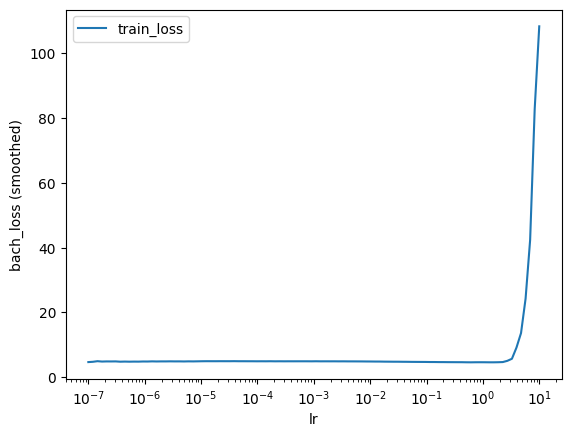

In [10]:
batch_size = 256
lrfinder = model.lr_finder(input=train_X, target=(train_durations,train_events), batch_size=batch_size)

_ = lrfinder.plot()

In [11]:
learning_rate = lrfinder.get_best_lr()

In [12]:
model.optimizer.set_lr(learning_rate)

In [13]:
epochs = 200
callbacks = [tt.torchtuples.callbacks.EarlyStopping()]
verbose = True

In [14]:
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.9496,	val_loss: 3.1083
1:	[0s / 0s],		train_loss: 4.7344,	val_loss: 3.1006
2:	[0s / 0s],		train_loss: 4.4561,	val_loss: 3.1583
3:	[0s / 0s],		train_loss: 4.4669,	val_loss: 2.9272
4:	[0s / 0s],		train_loss: 4.5371,	val_loss: 2.8500
5:	[0s / 0s],		train_loss: 4.2114,	val_loss: 2.9990
6:	[0s / 0s],		train_loss: 4.2311,	val_loss: 3.2385
7:	[0s / 0s],		train_loss: 4.2606,	val_loss: 3.2564
8:	[0s / 0s],		train_loss: 4.2259,	val_loss: 3.2268
9:	[0s / 0s],		train_loss: 4.1185,	val_loss: 3.1880
10:	[0s / 0s],		train_loss: 4.1820,	val_loss: 3.1417
11:	[0s / 0s],		train_loss: 4.2989,	val_loss: 3.1392
12:	[0s / 0s],		train_loss: 4.1161,	val_loss: 3.1908
13:	[0s / 0s],		train_loss: 4.0981,	val_loss: 3.3075
14:	[0s / 0s],		train_loss: 3.7166,	val_loss: 3.3219


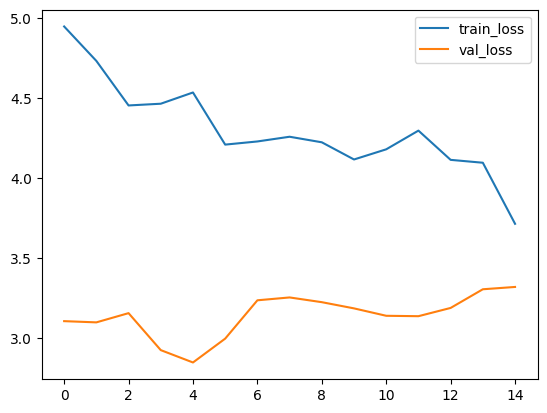

In [15]:
_ = log.plot()

In [16]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()
log.to_pandas().val_loss.idxmin()

4

Prediction

In [17]:
_ = model.compute_baseline_hazards()

In [18]:
surv = model.predict_surv_df(input=test_X)

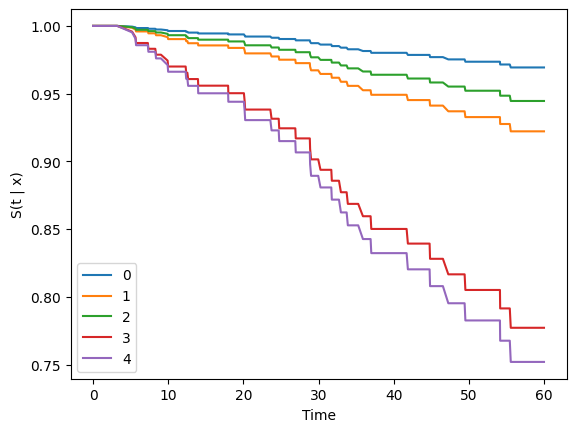

In [19]:
surv.iloc[:, :5].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel("Time")

Evaluation

In [20]:
test_durations = test_durations.cpu().detach().numpy()
test_events = test_events.cpu().detach().numpy()

In [21]:
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


In [22]:
ev.concordance_td()

0.6388888888888888

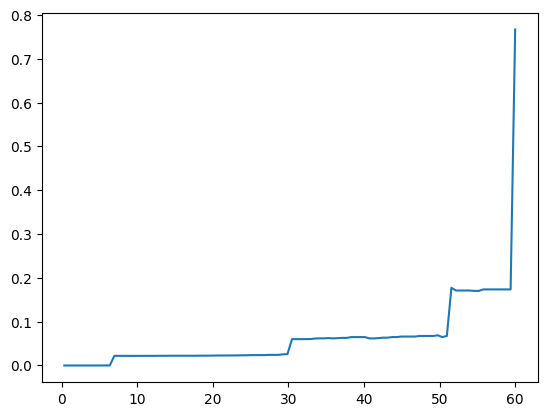

In [23]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [24]:
ev.integrated_brier_score(time_grid=time_grid)

0.05949756125373069

In [25]:
ev.integrated_nbll(time_grid)

0.21263785878946023